# Press release figure (MovieLens 25M)

Generates a three-panel figure for `PRESS_RELEASE.md`:

1. Rating distribution + dataset mean  
2. Held-out evaluation: global-mean baseline vs Surprise SVD (RMSE and MAE) + CV summary text  
3. Monthly rating activity (1995–2019)

**Requirements:** `duckdb`, `pandas`, `matplotlib`  
**Data:** `../code/data_output/ml-25m/ratings.csv

In [5]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Run this notebook with cwd = ds4320-project1/visualizations/
DATA_DIR = Path("../code/data_output/ml-25m").resolve()
RATINGS_CSV = DATA_DIR / "ratings.csv"

# Update these to match your latest pipeline output
BASELINE_RMSE = 1.061087
SVD_RMSE = 0.897354
BASELINE_MAE = 0.842030
SVD_MAE = 0.688093

CV_RMSE_MEAN = 0.901028
CV_RMSE_STD = 0.000411
CV_MAE_MEAN = 0.691496
CV_MAE_STD = 0.000440

OUT_PATH = Path("movielens_press_release.png")

if not RATINGS_CSV.is_file():
    raise FileNotFoundError(f"Missing ratings csv: {RATINGS_CSV}")

In [6]:
con = duckdb.connect(database=":memory:")

# 1) Rating distribution (exact counts per star value)
dist = con.execute(
    f"""
    SELECT rating, COUNT(*) AS cnt
    FROM read_csv('{RATINGS_CSV.as_posix()}')
    GROUP BY rating
    ORDER BY rating;
    """
).fetchdf()

# Dataset mean (weighted)
mean_rating = con.execute(
    f"""
    SELECT AVG(rating) AS mu
    FROM read_csv('{RATINGS_CSV.as_posix()}');
    """
).fetchdf()["mu"].iloc[0]

# 3) Monthly counts
monthly = con.execute(
    f"""
    SELECT
      date_trunc('month', to_timestamp(timestamp)) AS month,
      COUNT(*) AS cnt
    FROM read_csv('{RATINGS_CSV.as_posix()}')
    GROUP BY 1
    ORDER BY 1;
    """
).fetchdf()

con.close()

print("Mean rating:", float(mean_rating))
print("Monthly rows:", len(monthly))

Mean rating: 3.533854451353085
Monthly rows: 287


Saved: /Users/cmw/Desktop/s2026/ds4320/project1/ds4320-project1/visualizations/movielens_press_release.png


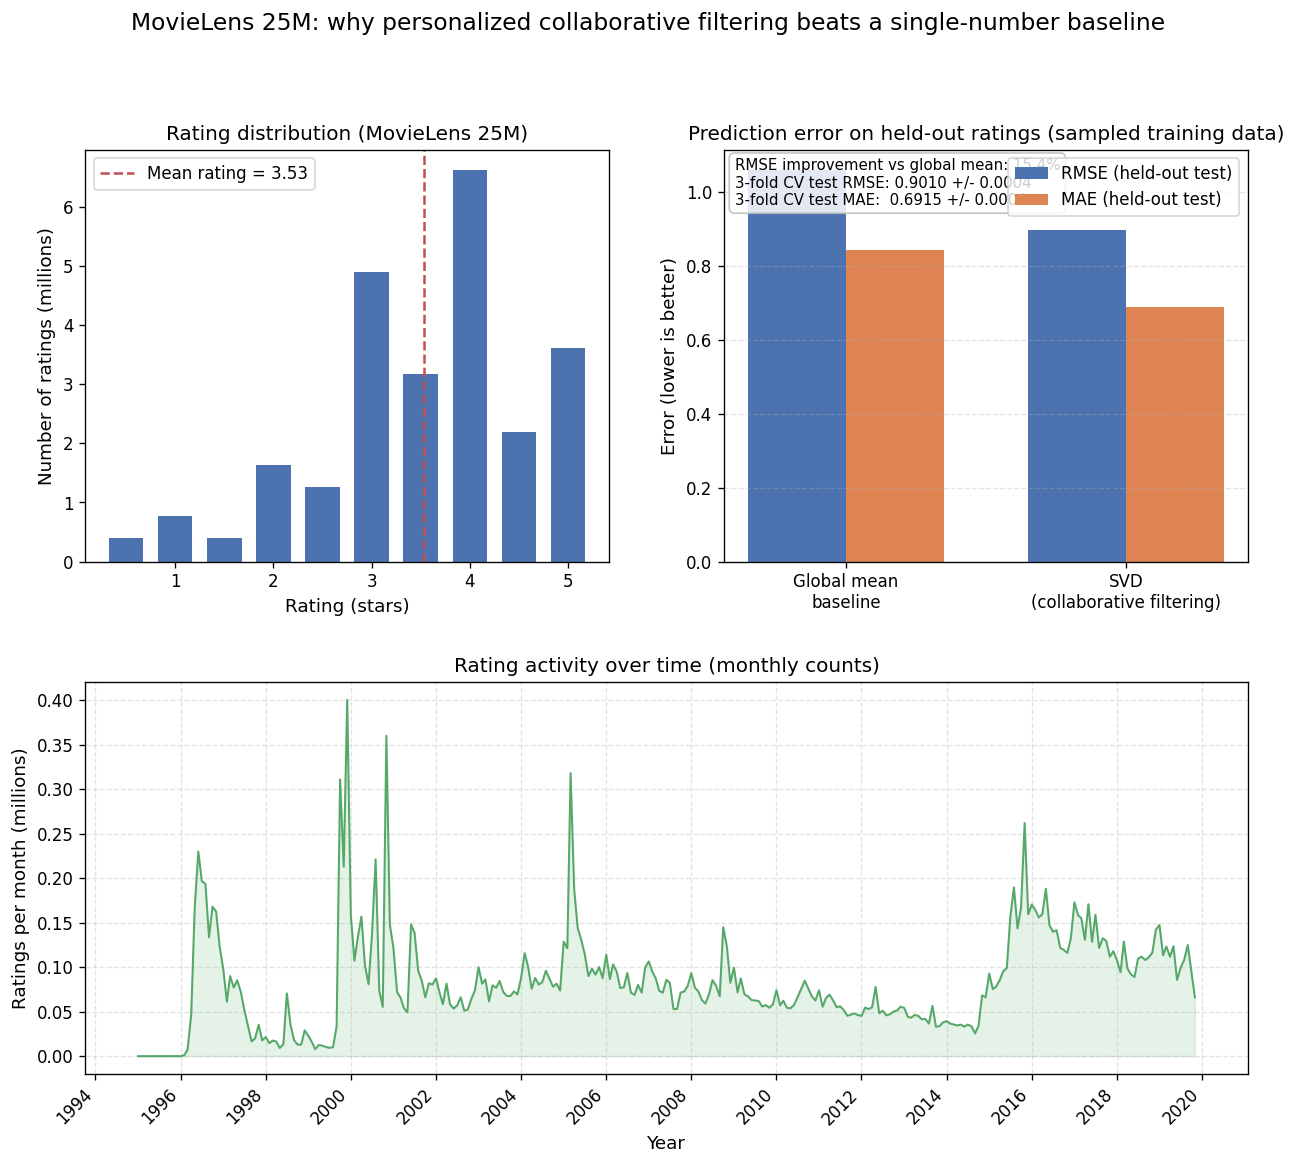

In [7]:
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    }
)

fig = plt.figure(figsize=(12.5, 10.0), constrained_layout=False)
gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.0], width_ratios=[1.0, 1.0], hspace=0.30, wspace=0.22)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# --- Panel 1: rating distribution ---
ax1.bar(dist["rating"].to_numpy(), dist["cnt"].to_numpy() / 1e6, width=0.35, color="#4C72B0")
ax1.axvline(float(mean_rating), color="#C44E52", linestyle="--", linewidth=1.5, label=f"Mean rating = {float(mean_rating):.2f}")
ax1.set_title("Rating distribution (MovieLens 25M)")
ax1.set_xlabel("Rating (stars)")
ax1.set_ylabel("Number of ratings (millions)")
ax1.legend(loc="upper left")

# --- Panel 2: baseline vs SVD (held-out) ---
labels = ["Global mean\nbaseline", "SVD\n(collaborative filtering)"]
x = np.arange(len(labels))
w = 0.35

rmse_vals = [BASELINE_RMSE, SVD_RMSE]
mae_vals = [BASELINE_MAE, SVD_MAE]

ax2.bar(x - w / 2, rmse_vals, width=w, label="RMSE (held-out test)", color="#4C72B0")
ax2.bar(x + w / 2, mae_vals, width=w, label="MAE (held-out test)", color="#DD8452")

ax2.set_xticks(x, labels)
ax2.set_title("Prediction error on held-out ratings (sampled training data)")
ax2.set_ylabel("Error (lower is better)")
ax2.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax2.legend(loc="upper right")

rmse_pct = 100.0 * (BASELINE_RMSE - SVD_RMSE) / BASELINE_RMSE
ax2.text(
    0.02,
    0.98,
    f"RMSE improvement vs global mean: {rmse_pct:.1f}%\n"
    f"3-fold CV test RMSE: {CV_RMSE_MEAN:.4f} +/- {CV_RMSE_STD:.4f}\n"
    f"3-fold CV test MAE:  {CV_MAE_MEAN:.4f} +/- {CV_MAE_STD:.4f}",
    transform=ax2.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="#BBBBBB"),
)

# --- Panel 3: temporal activity ---
monthly["month"] = pd.to_datetime(monthly["month"])
ax3.plot(monthly["month"], monthly["cnt"] / 1e6, color="#55A868", linewidth=1.2)
ax3.fill_between(monthly["month"], monthly["cnt"] / 1e6, color="#55A868", alpha=0.15)
ax3.set_title("Rating activity over time (monthly counts)")
ax3.set_xlabel("Year")
ax3.set_ylabel("Ratings per month (millions)")
ax3.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax3.xaxis.set_major_locator(mdates.YearLocator(2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")

fig.suptitle(
    "MovieLens 25M: why personalized collaborative filtering beats a single-number baseline",
    fontsize=14,
    y=0.995,
)

fig.savefig(OUT_PATH, bbox_inches="tight")
print("Saved:", OUT_PATH.resolve())